In [8]:
# Importing libraries we need 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [6]:
import os
os.listdir("../data")

['churn_labels.csv',
 'customers.csv',
 'DATA_DICTIONARY.md',
 'intervention_history.csv',
 'orders.csv',
 'rfm_modeling_snapshot.csv',
 'STUDENT_FACING_PROBLEM_STATEMENT.md',
 'support_tickets.csv',
 'web_events_snapshot.csv']

In [9]:
customers = pd.read_csv("../data/customers.csv")
customers.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


In [10]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   customer_id          2400 non-null   str  
 1   signup_date          2400 non-null   str  
 2   city_tier            2400 non-null   str  
 3   age_group            2400 non-null   str  
 4   acquisition_channel  2400 non-null   str  
 5   loyalty_tier         1014 non-null   str  
 6   preferred_category   2400 non-null   str  
 7   skin_type            1999 non-null   str  
 8   marketing_consent    2400 non-null   str  
dtypes: str(9)
memory usage: 168.9 KB


In [11]:
customers.isnull().sum()

customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

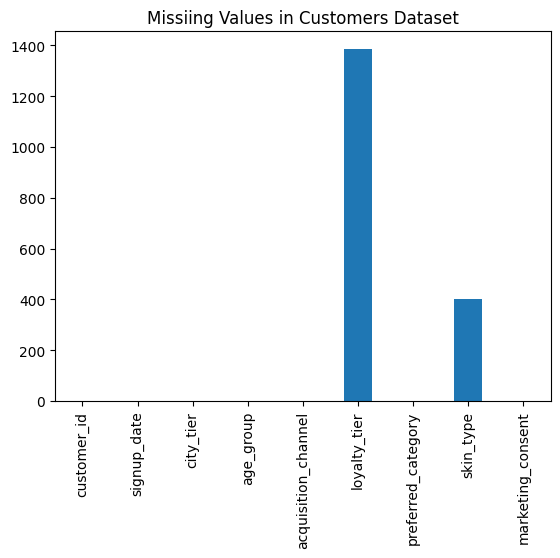

In [12]:
customers.isnull().sum().plot(kind="bar")
plt.title("Missiing Values in Customers Dataset")
plt.show()

In [13]:
customers["city_tier"].value_counts()

city_tier
Tier 1    1005
Tier 2     870
Tier 3     525
Name: count, dtype: int64

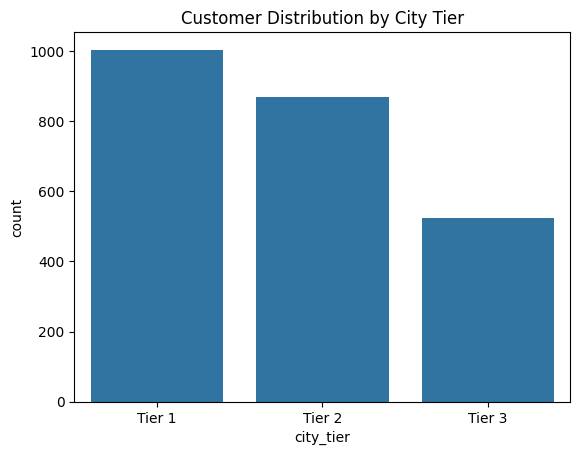

In [14]:
sns.countplot(x="city_tier", data=customers)
plt.title("Customer Distribution by City Tier")

plt.show()

In [15]:
customers["acquisition_channel"].value_counts()

acquisition_channel
Instagram        517
Google Search    466
Marketplace      456
Referral         396
Organic          334
Influencer       231
Name: count, dtype: int64

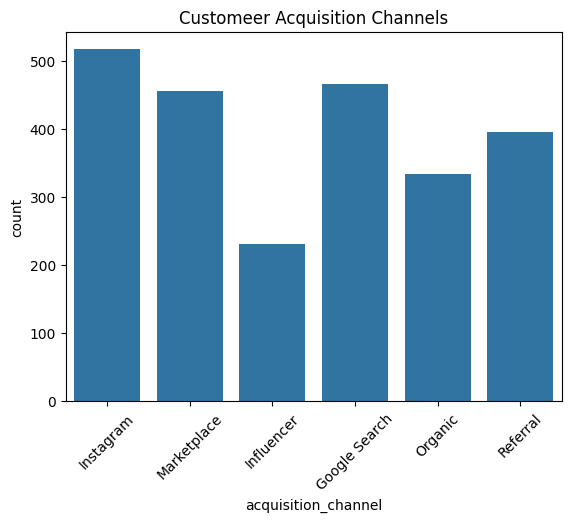

In [16]:
sns.countplot(x="acquisition_channel", data=customers)

plt.title("Customeer Acquisition Channels")
plt.xticks(rotation=45)      # we use rotation=45 because channel name may overlap on x-axis, This makes chart readable.
plt.show()

In [17]:
# Age group distribution
customers["age_group"].value_counts()

age_group
25-34    1045
18-24     560
35-44     534
45+       261
Name: count, dtype: int64

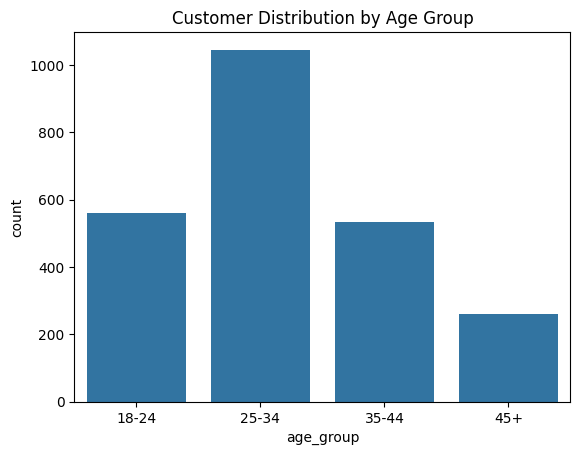

In [18]:
sns.countplot(x="age_group", data=customers)

plt.title("Customer Distribution by Age Group")
plt.show()

In [19]:
# Loyalty Tier Distribution 
customers["loyalty_tier"].value_counts()

loyalty_tier
Silver      590
Gold        319
Platinum    105
Name: count, dtype: int64

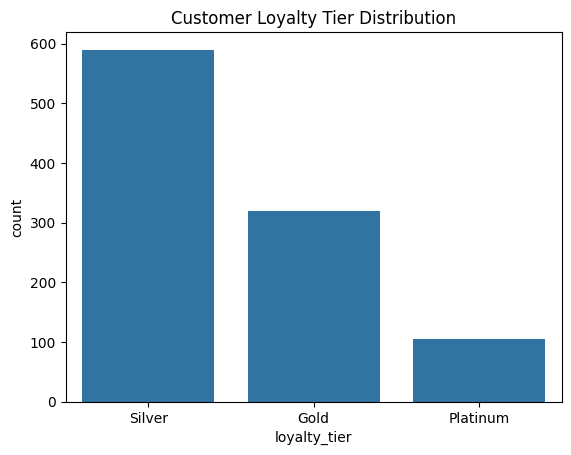

In [20]:
sns.countplot(x="loyalty_tier", data=customers)

plt.title("Customer Loyalty Tier Distribution")
plt.show()

In [21]:
#Preferred Product Categories
customers["preferred_category"].value_counts()

preferred_category
Skin Care    731
Hair Care    507
Baby Care    347
Makeup       326
Wellness     251
Fragrance    238
Name: count, dtype: int64

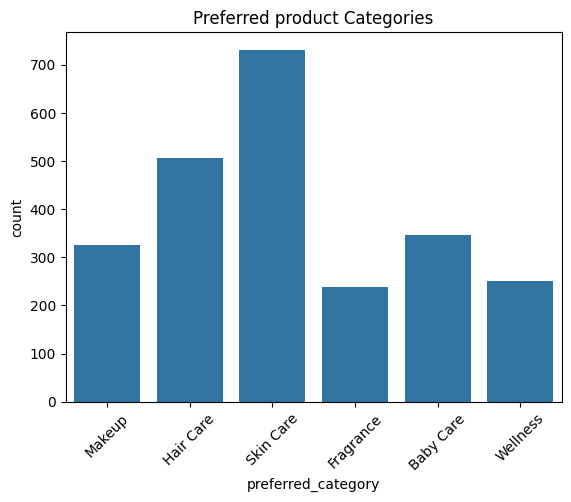

In [22]:
sns.countplot(x="preferred_category", data=customers)

plt.title("Preferred product Categories")
plt.xticks(rotation=45)
plt.show()

In [23]:
# Market Consent
customers["marketing_consent"].value_counts()

marketing_consent
Yes    1760
No      640
Name: count, dtype: int64

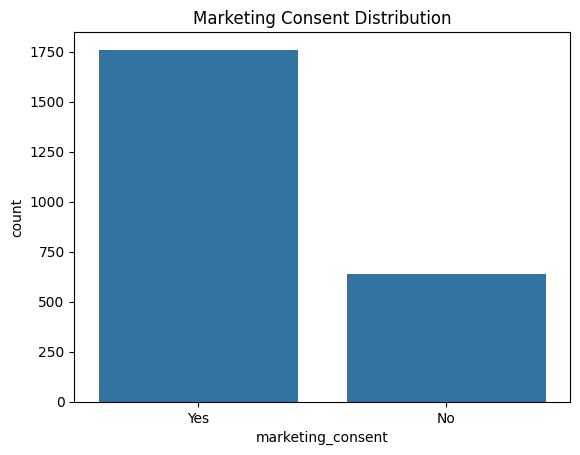

In [24]:
sns.countplot(x="marketing_consent", data=customers)

plt.title("Marketing Consent Distribution")
plt.show()

In [25]:
# Dataset Summary Statistics
customers.shape

(2400, 9)

In [26]:
customers.nunique()

customer_id            2400
signup_date             609
city_tier                 3
age_group                 4
acquisition_channel       6
loyalty_tier              3
preferred_category        6
skin_type                 5
marketing_consent         2
dtype: int64

In [27]:
customers.describe(include="all")

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
count,2400,2400,2400,2400,2400,1014,2400,1999,2400
unique,2400,609,3,4,6,3,6,5,2
top,CUST00001,2024-10-12,Tier 1,25-34,Instagram,Silver,Skin Care,Oily,Yes
freq,1,11,1005,1045,517,590,731,420,1760


In [28]:
# Loading Orders Dataset
orders = pd.read_csv("../data/orders.csv")
orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [29]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  str    
 1   customer_id    10009 non-null  str    
 2   order_date     10009 non-null  str    
 3   category       10009 non-null  str    
 4   quantity       10009 non-null  int64  
 5   gross_amount   10009 non-null  float64
 6   discount_pct   10009 non-null  float64
 7   delivery_days  10009 non-null  int64  
 8   returned       10009 non-null  int64  
 9   rating         9929 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 782.1 KB


In [30]:
orders.isnull().sum()

order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

In [31]:
orders.shape

(10009, 10)

In [32]:
orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [33]:
orders.describe()

,quantity,gross_amount,discount_pct,delivery_days,returned,rating
count,10009.000000,10009.000000,10009.000000,10009.000000,10009.000000,9929.000000
mean,1.507943,743.898504,0.274121,4.454591,0.067439,3.885487
std,0.764261,600.564068,0.125525,1.769649,0.250794,1.159465
min,1.000000,149.000000,0.000000,1.000000,0.000000,1.000000
25%,1.000000,432.850000,0.190000,3.000000,0.000000,3.000000
50%,1.000000,597.060000,0.270000,4.000000,0.000000,4.000000
75%,2.000000,907.430000,0.360000,6.000000,0.000000,5.000000
max,4.000000,24789.380000,0.700000,11.000000,1.000000,5.000000


In [34]:
orders.columns

Index(['order_id', 'customer_id', 'order_date', 'category', 'quantity',
       'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating'],
      dtype='str')

In [35]:
# Load Churn labels dataset
churn = pd.read_csv("../data/churn_labels.csv")

churn.head()

,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


In [36]:
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     2400 non-null   str  
 1   snapshot_date   2400 non-null   str  
 2   churn_next_60d  2400 non-null   int64
 3   split           2400 non-null   str  
dtypes: int64(1), str(3)
memory usage: 75.1 KB


In [37]:
churn["churn_next_60d"].value_counts()

churn_next_60d
0    1273
1    1127
Name: count, dtype: int64

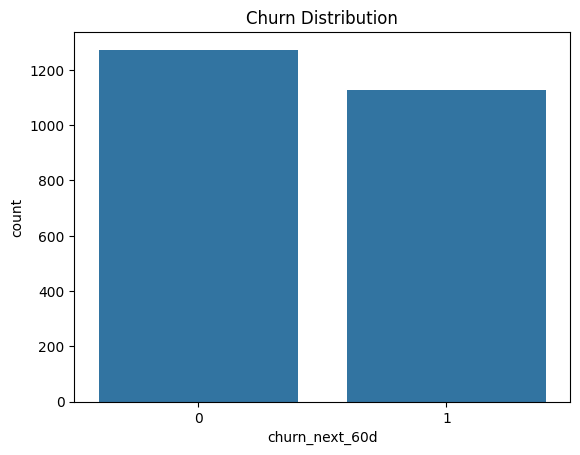

In [38]:
sns.countplot(x="churn_next_60d",data=churn)

plt.title("Churn Distribution")
plt.show()

In [39]:
support = pd.read_csv("../data/support_tickets.csv")
support.head()

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1


In [40]:
support.info()

<class 'pandas.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticket_id         1921 non-null   str    
 1   customer_id       1921 non-null   str    
 2   ticket_date       1921 non-null   str    
 3   issue_type        1921 non-null   str    
 4   support_channel   1921 non-null   str    
 5   resolution_hours  1921 non-null   float64
 6   sentiment_score   1921 non-null   float64
 7   reopened          1921 non-null   int64  
dtypes: float64(2), int64(1), str(5)
memory usage: 120.2 KB


In [42]:
orders.columns

Index(['order_id', 'customer_id', 'order_date', 'category', 'quantity',
       'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating'],
      dtype='str')

In [44]:
# Summary Statistics 
orders.describe()

,quantity,gross_amount,discount_pct,delivery_days,returned,rating
count,10009.000000,10009.000000,10009.000000,10009.000000,10009.000000,9929.000000
mean,1.507943,743.898504,0.274121,4.454591,0.067439,3.885487
std,0.764261,600.564068,0.125525,1.769649,0.250794,1.159465
min,1.000000,149.000000,0.000000,1.000000,0.000000,1.000000
25%,1.000000,432.850000,0.190000,3.000000,0.000000,3.000000
50%,1.000000,597.060000,0.270000,4.000000,0.000000,4.000000
75%,2.000000,907.430000,0.360000,6.000000,0.000000,5.000000
max,4.000000,24789.380000,0.700000,11.000000,1.000000,5.000000


In [45]:
# Categorical columns distribution
orders["category"].value_counts()

category
Skin Care    2700
Hair Care    2191
Makeup       1507
Baby Care    1438
Wellness     1096
Fragrance    1077
Name: count, dtype: int64

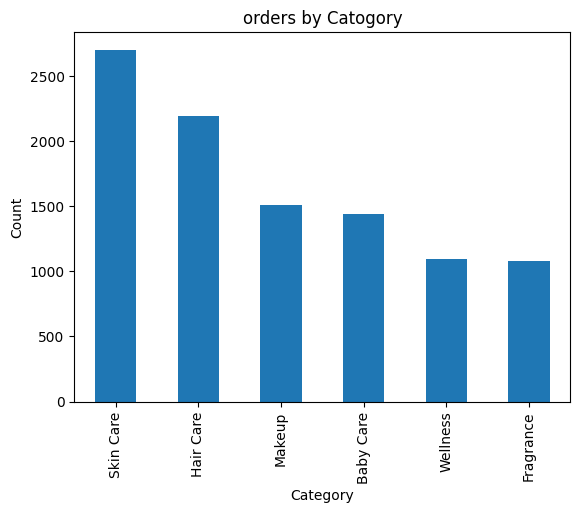

In [46]:
# first Sale Visualization
orders["category"].value_counts().plot(kind="bar")
plt.title("orders by Catogory")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

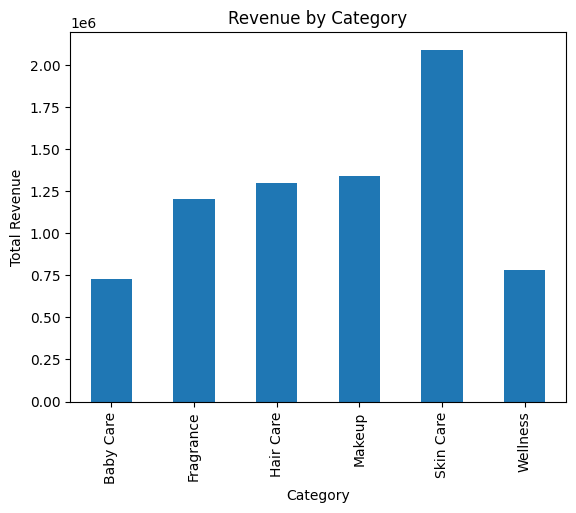

In [50]:
# Checking revenue by category
orders.groupby("category")["gross_amount"].sum().plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.show()

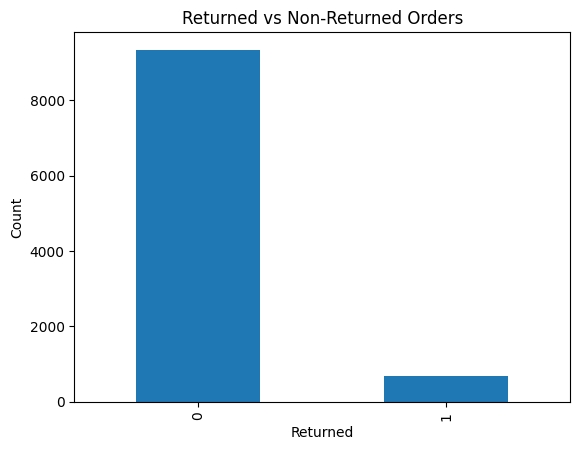

In [52]:
# Checking returned orders distribution

orders["returned"].value_counts().plot(kind="bar")
plt.title("Returned vs Non-Returned Orders") # 0 = Non-Returned Orders and 1 = Returned Orders
plt.xlabel("Returned")
plt.ylabel("Count")

plt.show()

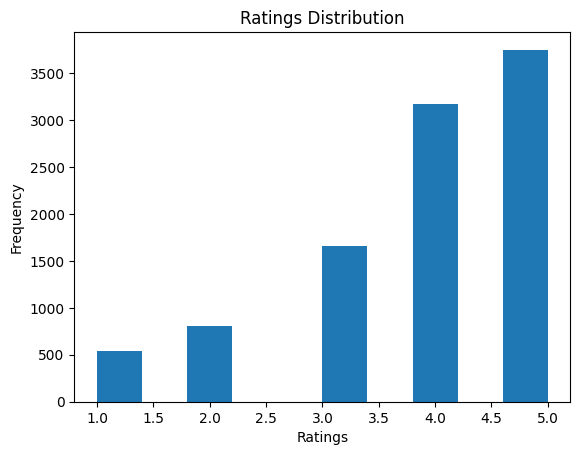

In [54]:
# Checking rating distribution

orders["rating"].plot(kind="hist")

plt.title("Ratings Distribution")
plt.xlabel("Ratings")
plt.ylabel("Frequency")

plt.show()

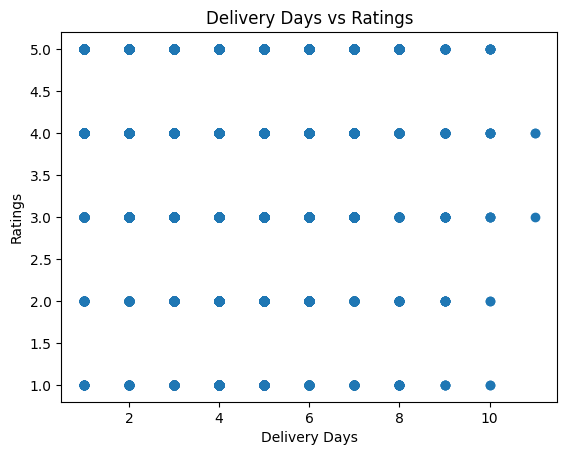

In [55]:
# Checking relationship between delivery days and ratings

plt.scatter(orders["delivery_days"],orders["rating"])

plt.title("Delivery Days vs Ratings")
plt.xlabel("Delivery Days")
plt.ylabel("Ratings")

plt.show()

In [56]:
# Observation:
# Ratings are spread across different delivery days.
# No strong relationship is clearly visible from this scatter plot.

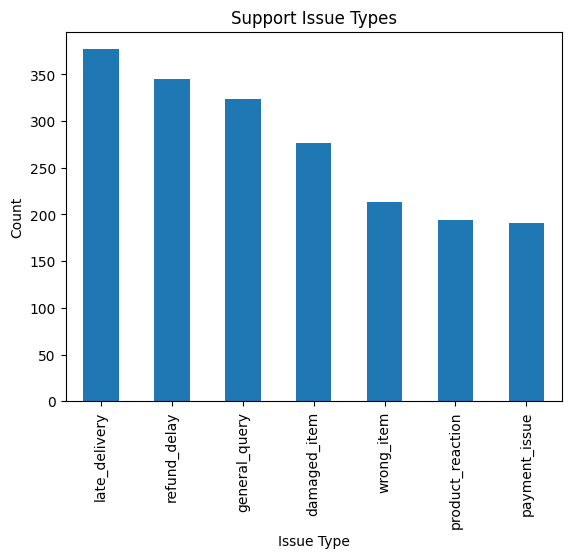

In [57]:
# Checking issue type distribution

support["issue_type"].value_counts().plot(kind="bar")

plt.title("Support Issue Types")
plt.xlabel("Issue Type")
plt.ylabel("Count")

plt.show()

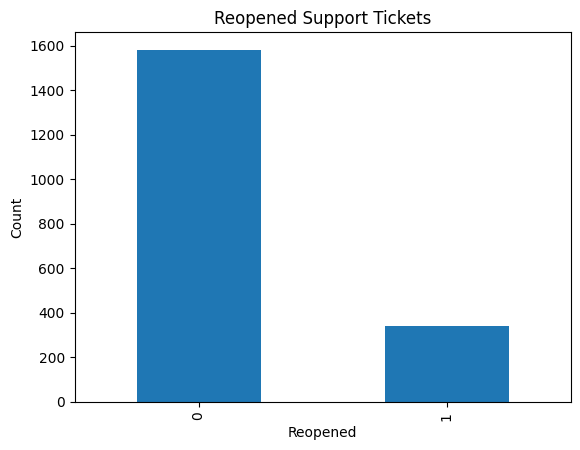

In [58]:
# Checking reopened tickets distribution

support["reopened"].value_counts().plot(kind="bar")

plt.title("Reopened Support Tickets")
plt.xlabel("Reopened")
plt.ylabel("Count")

plt.show()

In [60]:
# Observation:
# Most tickets were not reopened.
# Very few tickets needed reopening after resolution.

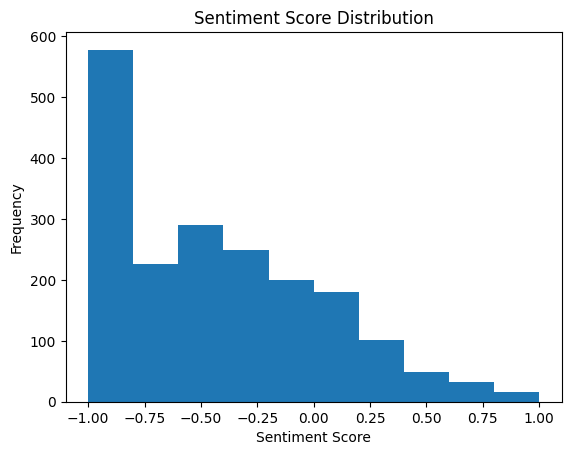

In [61]:
# Checking sentiment score distribution

support["sentiment_score"].plot(kind="hist")

plt.title("Sentiment Score Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")

plt.show()

In [62]:
# Observation:
# Sentiment scores help understand customer emotions.
# Negative values indicate unhappy customers,
# while positive values indicate satisfied customers.

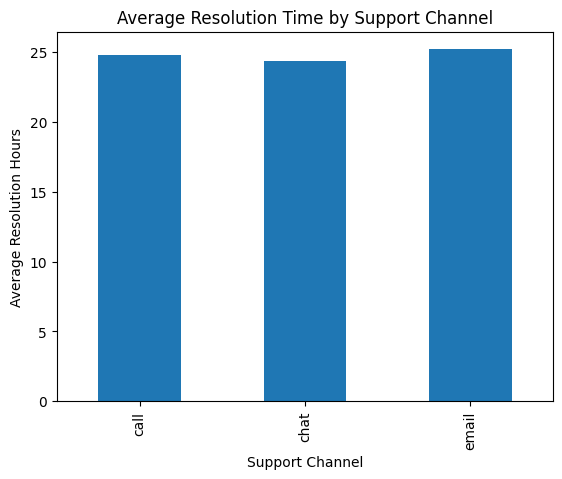

In [63]:
# Checking average resolution time by support channel

support.groupby("support_channel")["resolution_hours"].mean().plot(kind="bar")

plt.title("Average Resolution Time by Support Channel")
plt.xlabel("Support Channel")
plt.ylabel("Average Resolution Hours")

plt.show()

In [64]:
# Observation:
# This graph shows which support channel
# takes more time to resolve customer issues.

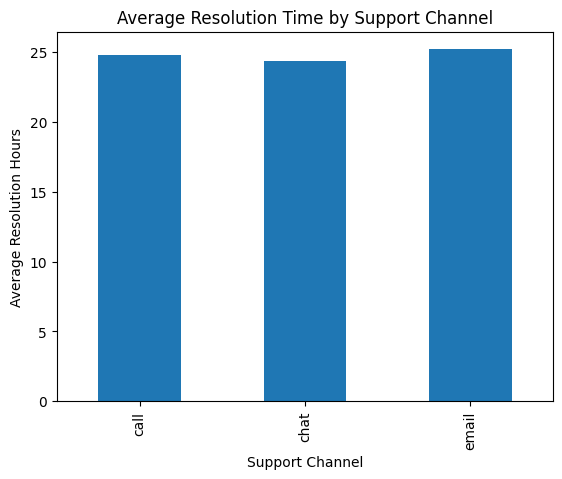

In [65]:
# Checking average resolution time by support channel

support.groupby("support_channel")["resolution_hours"].mean().plot(kind="bar")

plt.title("Average Resolution Time by Support Channel")
plt.xlabel("Support Channel")
plt.ylabel("Average Resolution Hours")

plt.show()

In [66]:
# Observation:
# This graph compares average resolution time
# across different support channels.
# Higher resolution hours may indicate slower support service.

In [67]:
# Checking correlation between numerical columns

orders[["gross_amount", "discount_pct", "delivery_days", "rating"]].corr()

,gross_amount,discount_pct,delivery_days,rating
gross_amount,1.000000,-0.212764,0.003603,0.012277
discount_pct,-0.212764,1.000000,0.009607,0.003555
delivery_days,0.003603,0.009607,1.000000,-0.016577
rating,0.012277,0.003555,-0.016577,1.000000


#### Observation

In [70]:
# Correlation values near 0 indicate weak relationships.
# Positive values indicate direct relationships.
# Negative values indicate inverse relationships.

#### Final Business Insights

In [72]:
# 1. Most customers give high ratings (4-5 stars).
# 2. Returned orders are very low compared to successful orders.
# 3. Some support tickets have negative sentiment scores.
# 4. Revenue varies across product categories.
# 5. Support resolution time differs by support channel.